# Contenido

Estabilidad de variables:

1.   Estabilidad de variables y scores
2.   Evaluación de modelos
3.   Evaluación de negocio
3.   Proveedores de servicios de MLOps
4.   Visualizadores del monitoreo



### Referencias

https://cloud.google.com/architecture/mlops-continuous-delivery-and-automation-pipelines-in-machine-learning#devops_versus_mlops

https://dashboard.ngrok.com/

https://mlflow.org/

# Estabilidad de variables y scores
Debemos medir la distancia entre las distribuciones de probabilidad las variables y los scores.

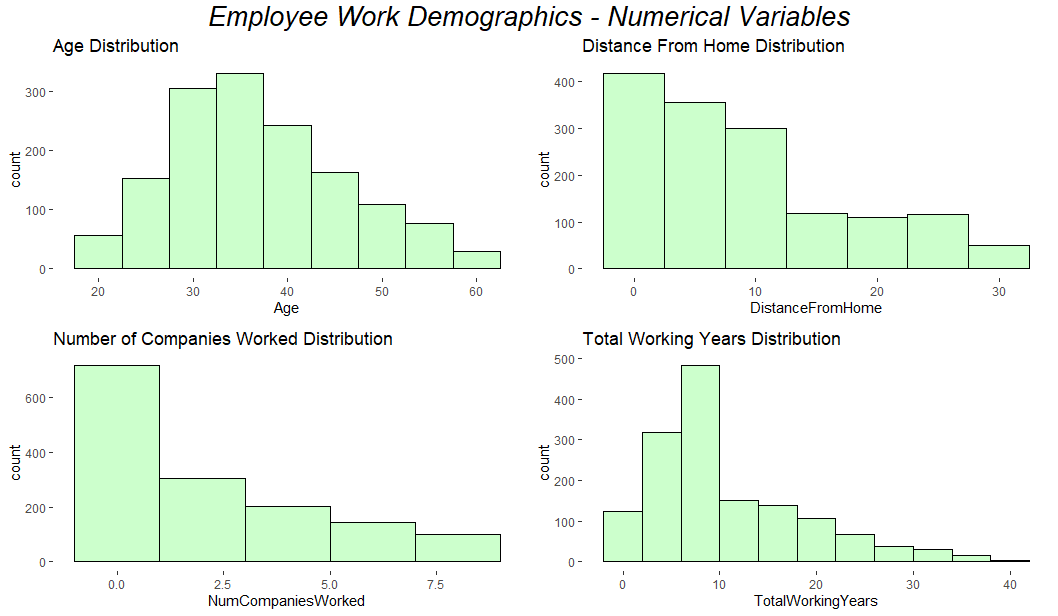

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Docencia UCSP/Maestría DS 2024 - aplicaciones prácticas/Dataset/Data_CU_venta.csv')
df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,p_codmes,key_value,target,monto,ctd_prod_rccsf_m01,prom_salvig_entprinc_pp_rccsf_03m,max_usotcrrstsf06m,max_usotcrrstsf03m,prm_lintcribksf06m,lin_tcribksf03m,...,beta_saltotppe12m,prm_entrd03m,ctd_entrdm01,beta_saltotppe06m,prm_diasatrrd03m,prm_saltotrdpj03m,prm_saltotrdpj12m,dsv_diasatrrdpj12m,max_pctsalimpago12m,prm_diasatrrdpj03m
0,201912.0,2A7AA560ED5426EEBCBA5678510D53FDE5C30E3E309BC1...,0,15000.0,6,0.000,0.015,0.015,9400.000,28200.00,...,NaN,1.667,2.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN
1,201912.0,7581203BF579C305ED0A62F8374CACD0925F7BA1C70DD2...,0,44800.0,1,0.000,0.000,0.000,10000.000,30000.00,...,NaN,1.333,1.0,NaN,0.0,57500.0,60500.000,0.0,NaN,0.0
2,201912.0,3B9C6C94C9274C64DFC7FE325931589B1C2B5B229600A1...,0,12200.0,7,3515.793,0.223,0.194,18500.000,55500.00,...,-67.669,4.667,5.0,-80.264,0.0,NaN,NaN,NaN,NaN,NaN
3,201912.0,8C9FB47C7499B7C65224D77D1BBB1C78F3AA2F4920EBF0...,0,21300.0,2,0.000,0.831,0.481,4900.000,14700.00,...,NaN,2.000,2.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN
4,201912.0,4A68666AF9B98056E7B257CB44957A92EA587DAC9DB1A7...,0,36000.0,2,0.000,0.809,0.809,9000.000,27000.00,...,NaN,2.000,2.0,NaN,0.0,NaN,131.075,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79081,201911.0,A4E5482EFEF2807DDB7813E9528498FCF5F6B81B7C6D09...,0,10200.0,4,0.000,0.524,0.490,20475.685,57574.37,...,-95.630,3.667,3.0,NaN,0.0,NaN,NaN,NaN,0.049,NaN
79082,201911.0,D6E4A8D42587BEBF504FCB8E79EA254BB9BE96619D5CED...,0,12800.0,6,5494.263,0.487,0.020,6116.667,19000.00,...,-423.127,3.667,3.0,-1297.086,0.0,NaN,NaN,NaN,0.023,NaN
79083,201911.0,5B03358580A8D6ADA03582E7D97D50F62C674C0090F383...,0,9600.0,6,10783.380,0.401,0.401,9000.000,27000.00,...,-1975.294,5.333,5.0,-779.508,0.0,NaN,NaN,NaN,NaN,NaN
79084,201911.0,322A9C737747747C0AB31D867299634FF28FC92BBA0EA3...,0,30000.0,3,0.000,0.039,0.039,60000.000,180000.00,...,NaN,2.667,2.0,NaN,0.0,NaN,NaN,NaN,NaN,NaN


In [3]:
df.p_codmes.unique()

array([201912., 201910., 201911., 201909.,     nan])

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
p_codmes,77884.0,201910.578964,1.105269,201909.00,201910.0000,201911.000,201912.00000,2.019120e+05
target,79086.0,0.037883,0.190914,0.00,0.0000,0.000,0.00000,1.000000e+00
monto,77884.0,23110.271686,15716.874469,100.00,11900.0000,19600.000,30000.00000,1.500000e+05
ctd_prod_rccsf_m01,79086.0,4.083175,1.841823,0.00,3.0000,4.000,5.00000,1.200000e+01
prom_salvig_entprinc_pp_rccsf_03m,79086.0,6895.058693,20345.406039,0.00,0.0000,0.000,4536.32925,6.922512e+05
...,...,...,...,...,...,...,...,...
prm_saltotrdpj03m,3038.0,9831.277634,19106.672942,3.31,1579.5085,4330.399,10161.20400,4.930500e+05
prm_saltotrdpj12m,4519.0,13400.035769,39289.022275,1.43,1752.9655,4885.587,12766.40800,1.275240e+06
dsv_diasatrrdpj12m,4645.0,0.210160,1.337057,0.00,0.0000,0.000,0.00000,3.539686e+01
max_pctsalimpago12m,11164.0,0.230825,0.320730,0.00,0.0080,0.062,0.33200,1.000000e+00


# **Medición de distancia entre 2 conjuntos de probabilidad - data drift**

PSI metric:
https://arize.com/blog-course/population-stability-index-psi/

KL divergence:
https://medium.com/data-science/understanding-kl-divergence-f3ddc8dff254


**Data drift**
obtener el tamaño (referencia | muestra actual)
dividirlo en quantiles (referencia | muestra actual)
De cada quantil sacar media y mediana y obtener el ratio respècto a la referencia
for var in vars:
  **rat_est_var_1 = Media(DF_actual(Var_1))/Media(DF_referencia(Var_1))**
  rat decaimiento por variable por mes respecto al mes de referencia

def ratio de decaimiento(df_actual, df_ref, quantils):
        ratio menor a 5% check
        ratio entre 5 a 15% regular
        ratio mayor 15% warning


array([201912., 201911., 201910., *201909*.])
 var_1  1.2%       1%     1.1%        0
 var_2  
  ...
 var_n




In [6]:
def calculate_ratio_dec(expected_array, actual_array, buckets):#buckets o quantiles
    breakpoints = np.percentile(expected_array, np.linspace(0, 100, buckets + 1))
    breakpoints[0] = -np.inf  # para incluir todos los valores
    breakpoints[-1] = np.inf

    expected_counts = np.histogram(expected_array, bins=breakpoints)[0] / len(expected_array)
    actual_counts = np.histogram(actual_array, bins=breakpoints)[0] / len(actual_array)

    # Evita divisiones por cero o log(0)
    expected_counts = np.where(expected_counts == 0, 1e-6, expected_counts)
    actual_counts = np.where(actual_counts == 0, 1e-6, actual_counts)

    # Acá se hace el cálculo - Reemplazar por cualquier método
    # si el ratio es 0 entonces no hay drift, si es 1 si hay drift
    ratios = np.mean(expected_counts)/ np.mean(actual_counts)
    return 1-np.mean(ratios)

def ratio_dec_alert(ratios): #Podemos cambiar los umbrales según la criticidad de la variable
  if ratios < 0.05:
    return 'check'
  elif ratios < 0.15:
    return 'regular'
  else:
    return 'warning'

def ratio_decaimiento(df, df_ref, quantils): #dataframe actual, dataframe referencia, cant particiones
  results = []
  for col in df.columns: #el input pudieron ser las columnas
    if pd.api.types.is_numeric_dtype(df[col]) and pd.api.types.is_numeric_dtype(df_ref[col]): #solo está pensado
      ratios = calculate_ratio_dec(df_ref[col].dropna().values, df[col].dropna().values, quantils) #esto es considerando que hay datos crudos
      alert = ratio_dec_alert(ratios)
      results.append({'feature': col, 'ratios': ratios, 'alert': alert})
  return pd.DataFrame(results).set_index('feature')

In [10]:
ratio_decaimiento(df[df.p_codmes == 201911], df[df.p_codmes == 201909], 1000)

,ratios,alert
feature,,
p_codmes,0.000000e+00,check
target,0.000000e+00,check
monto,2.220446e-16,check
ctd_prod_rccsf_m01,0.000000e+00,check
prom_salvig_entprinc_pp_rccsf_03m,4.440892e-16,check
...,...,...
prm_saltotrdpj03m,2.518532e-04,check
prm_saltotrdpj12m,4.388025e-04,check
dsv_diasatrrdpj12m,2.297778e-05,check


# **Population Stability Index (PSI)**
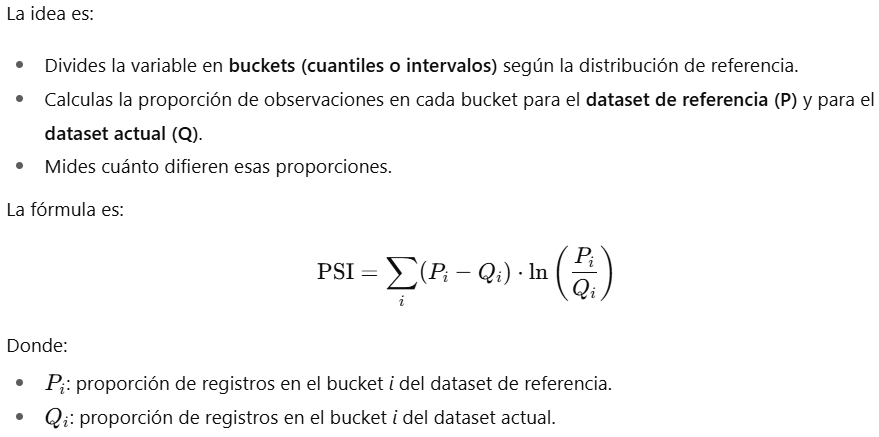

Umbrales de alerta:
'normal' si es menor del 5%
'alerta menor' si es menor al 15% y mayor al 5%
'critico' mayor al 15%

In [11]:
def calculate_psi(expected_array, actual_array, buckets):#buckets o quantiles
    breakpoints = np.percentile(expected_array, np.linspace(0, 100, buckets + 1))
    breakpoints[0] = -np.inf  # para incluir todos los valores
    breakpoints[-1] = np.inf

    expected_counts = np.histogram(expected_array, bins=breakpoints)[0] / len(expected_array)
    actual_counts = np.histogram(actual_array, bins=breakpoints)[0] / len(actual_array)

    # Evita divisiones por cero o log(0)
    expected_counts = np.where(expected_counts == 0, 1e-6, expected_counts)
    actual_counts = np.where(actual_counts == 0, 1e-6, actual_counts)

    # calculo del PSI
    psi_values = (expected_counts - actual_counts) * np.log(expected_counts / actual_counts)
    return np.sum(psi_values)

def psi_alert(psi):
  if psi < 0.05:
    return 'check'
  elif psi < 0.15:
    return 'regular'
  else:
    return 'warning'

def PSI(df, df_ref, quantils): #dataframe actual, dataframe referencia, cant particiones
  results = []
  for col in df.columns: #el input pudieron ser las columnas
    if pd.api.types.is_numeric_dtype(df[col]) and pd.api.types.is_numeric_dtype(df_ref[col]):
      psi = calculate_psi(df_ref[col].dropna().values, df[col].dropna().values, quantils)
      alert = psi_alert(psi)
      results.append({'feature': col, 'psi': psi, 'alert': alert})
  return pd.DataFrame(results).set_index('feature')

In [16]:
PSI(df[df.p_codmes == 201911], df[df.p_codmes == 201909], 1000) #df_actual, df_referencia, quantils/buckets

,psi,alert
feature,,
p_codmes,0.000000,check
target,0.000752,check
monto,0.069305,regular
ctd_prod_rccsf_m01,0.005322,check
prom_salvig_entprinc_pp_rccsf_03m,0.050198,regular
...,...,...
prm_saltotrdpj03m,6.935961,warning
prm_saltotrdpj12m,3.666006,warning
dsv_diasatrrdpj12m,0.231630,warning


# **Divergencia KL**
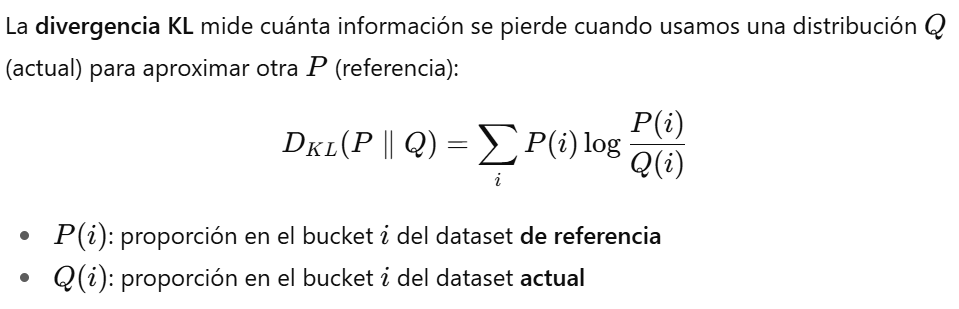

In [18]:
def calculate_kl(expected_array, actual_array, buckets):#buckets o quantiles
    breakpoints = np.percentile(expected_array, np.linspace(0, 100, buckets + 1))
    breakpoints[0] = -np.inf  # para incluir todos los valores
    breakpoints[-1] = np.inf

    expected_counts = np.histogram(expected_array, bins=breakpoints)[0] / len(expected_array)
    actual_counts = np.histogram(actual_array, bins=breakpoints)[0] / len(actual_array)

    # Evita divisiones por cero o log(0)
    expected_counts = np.where(expected_counts == 0, 1e-6, expected_counts)
    actual_counts = np.where(actual_counts == 0, 1e-6, actual_counts)

    # calculo del KL
    kl_div_values = expected_counts * np.log(expected_counts / actual_counts) #expected_counts: referencia
    return np.sum(kl_div_values)

def kl_alert(kl):
  if kl < 0.05:
    return 'check'
  elif kl < 0.15:
    return 'regular'
  else:
    return 'warning'

def KL_div(df, df_ref, quantils): #dataframe actual, dataframe referencia, cant particiones
  results = []
  for col in df.columns: #el input pudieron ser las columnas
    if pd.api.types.is_numeric_dtype(df[col]) and pd.api.types.is_numeric_dtype(df_ref[col]):
      kl = calculate_kl(df_ref[col].dropna().values, df[col].dropna().values, quantils)
      alert = kl_alert(kl)
      results.append({'feature': col, 'kl_div': kl, 'alert': alert})
  return pd.DataFrame(results).set_index('feature')

In [19]:
KL_div(df[df.p_codmes == 201911], df[df.p_codmes == 201909], 1000)

,kl_div,alert
feature,,
p_codmes,0.000000,check
target,0.000368,check
monto,0.035188,check
ctd_prod_rccsf_m01,0.002500,check
prom_salvig_entprinc_pp_rccsf_03m,0.023974,check
...,...,...
prm_saltotrdpj03m,3.999339,warning
prm_saltotrdpj12m,2.856320,warning
dsv_diasatrrdpj12m,0.175083,warning


**Ejercicio 25 mins - 21:40**

Comparar las métricas PSI y KL para el df de ejemplo, siendo:
df[201909] la referencia - o distribución esperada
Y todas las demás las distribuciones actuales.

Luego plotear el valor de cada métrica mes a mes.

Les debe salir está imagen de referencia:

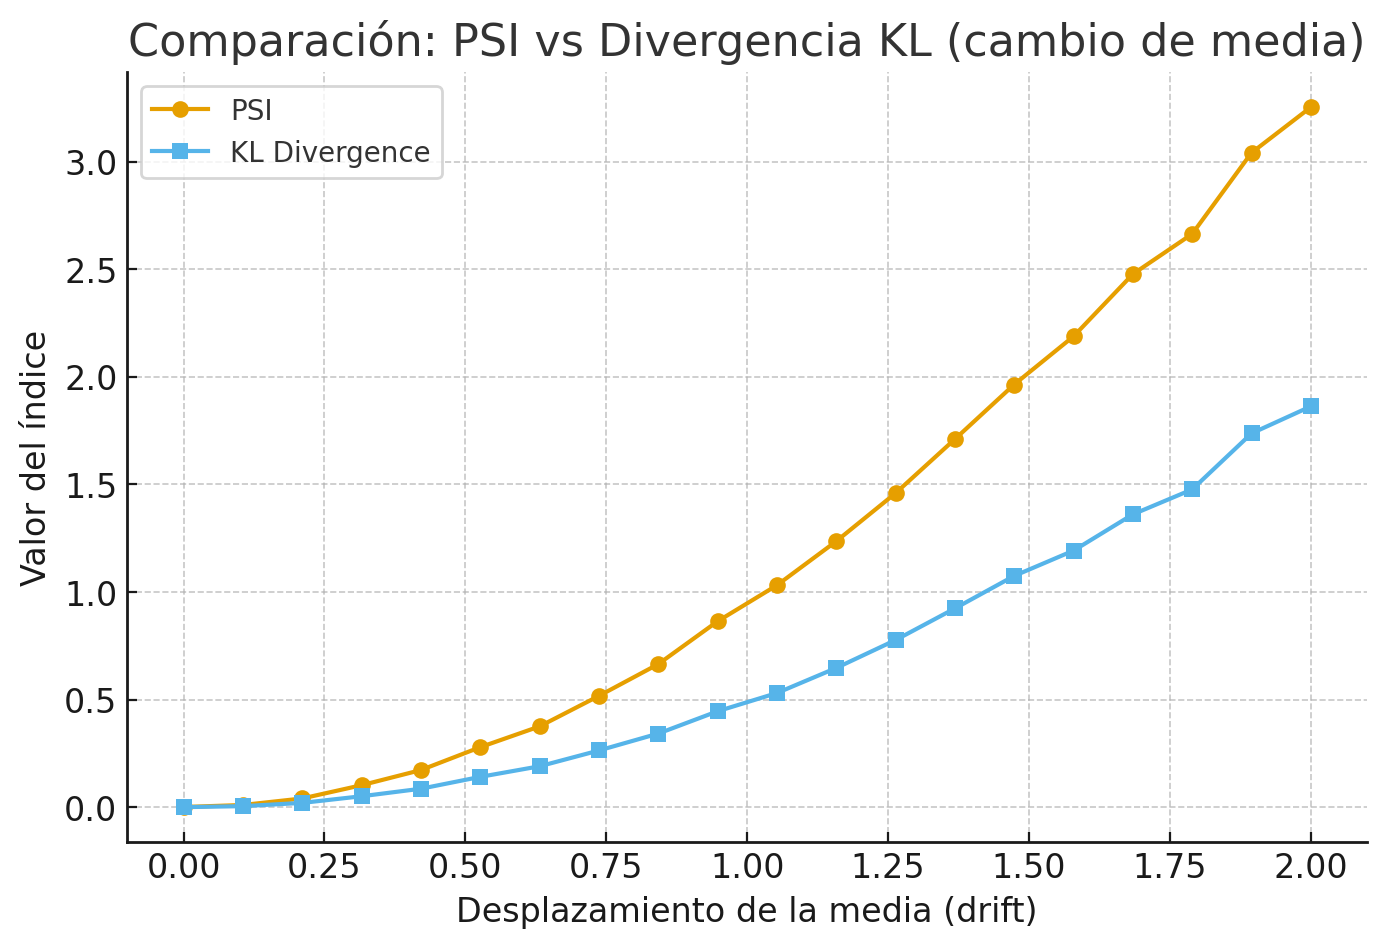